Opening file explorer... (Check your taskbar if it doesn't pop up immediately)
Image successfully loaded from: C:/Users/ADV/Universita/Magistrale/Tesi/vad-project/data/extracted_frames/1_disassembled_controlled_caos_f0006.jpg


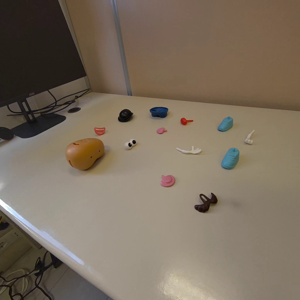

In [23]:
# Cell 1: Select Image via OS File Explorer (tkinter)
import tkinter as tk
from tkinter import filedialog
from PIL import Image
from IPython.display import display
import os

print("Opening file explorer... (Check your taskbar if it doesn't pop up immediately)")

# Initialize tkinter
root = tk.Tk()
root.attributes('-topmost', True)  # Force window to the front
root.withdraw()  # Hide the root window

# Open the native OS file dialog
image_path = filedialog.askopenfilename(
    title="Select an Image",
    initialdir="../data/extracted_frames/",
    filetypes=[
        ("Image Files", "*.jpg;*.jpeg;*.png"),
        ("All Files", "*.*")
    ]
)

# Destroy the root window to prevent Jupyter from freezing
root.destroy()

if image_path and os.path.exists(image_path):
    print(f"Image successfully loaded from: {image_path}")
    image = Image.open(image_path).convert('RGB')
    
    # Show a small preview in the notebook
    preview = image.copy()
    preview.thumbnail((300, 300))
    display(preview)
else:
    print("No image selected or file not found. Please run the cell again.")

In [ ]:
# Cell 2: Load C-RADIOv4 model
import os
import torch
from transformers import AutoModel, CLIPImageProcessor

# Adjusted path to match the directory depth of your data folder
local_repo = "../models/c_radio_weights" 

# Verify the directory exists before trying to load
if not os.path.exists(local_repo):
    print(f"ERROR: Cannot find the directory at:\n{os.path.abspath(local_repo)}")
    print("Please verify the exact name and location of your 'c_radio_weights' folder.")
else:
    print(f"Loading model from local path: {os.path.abspath(local_repo)}...")
    
    image_processor = CLIPImageProcessor.from_pretrained(local_repo)
    model = AutoModel.from_pretrained(local_repo, trust_remote_code=True)
    model.eval().cuda()
    
    print("Model loaded successfully into VRAM!")

Loading model from local path: c:\Users\ADV\Universita\Magistrale\Tesi\vad-project\models\c_radio_weights...


C:\Users\ADV\.cache\huggingface\modules\transformers_modules\c_radio_weights\aaeed1bbd1ae216f\extra_models.py:80: UserWarning: Overwriting paligemma_896_student in registry with transformers_modules.c_radio_weights.aaeed1bbd1ae216f.extra_models.paligemma_896_student. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  def paligemma_896_student(**kwargs):
C:\Users\ADV\.cache\huggingface\modules\transformers_modules\c_radio_weights\aaeed1bbd1ae216f\extra_models.py:204: UserWarning: Overwriting dino_v2_l_student in registry with transformers_modules.c_radio_weights.aaeed1bbd1ae216f.extra_models.dino_v2_l_student. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  def dino_v2_l_student(**kwargs):
C:\Users\ADV\.cache\huggingface\modules\transformers_modules\c_radio_weights\aaeed1bbd1ae216f\extra_models.py:208: UserWarning: Overwriting dino_v2_g_student in registry w

Loading weights:   0%|          | 0/330 [00:00<?, ?it/s]

✅ Model loaded successfully into VRAM!


1. Calculating optimal high-resolution input...
Original size: 1024x1024 -> Target size: 1024x1024
2. Extracting high-density spatial features...
Feature grid size: 64x64 patches
3. Computing Robust PCA (Fitting only on central features)...
4. Normalizing for RGB visualization...
5. Plotting results...


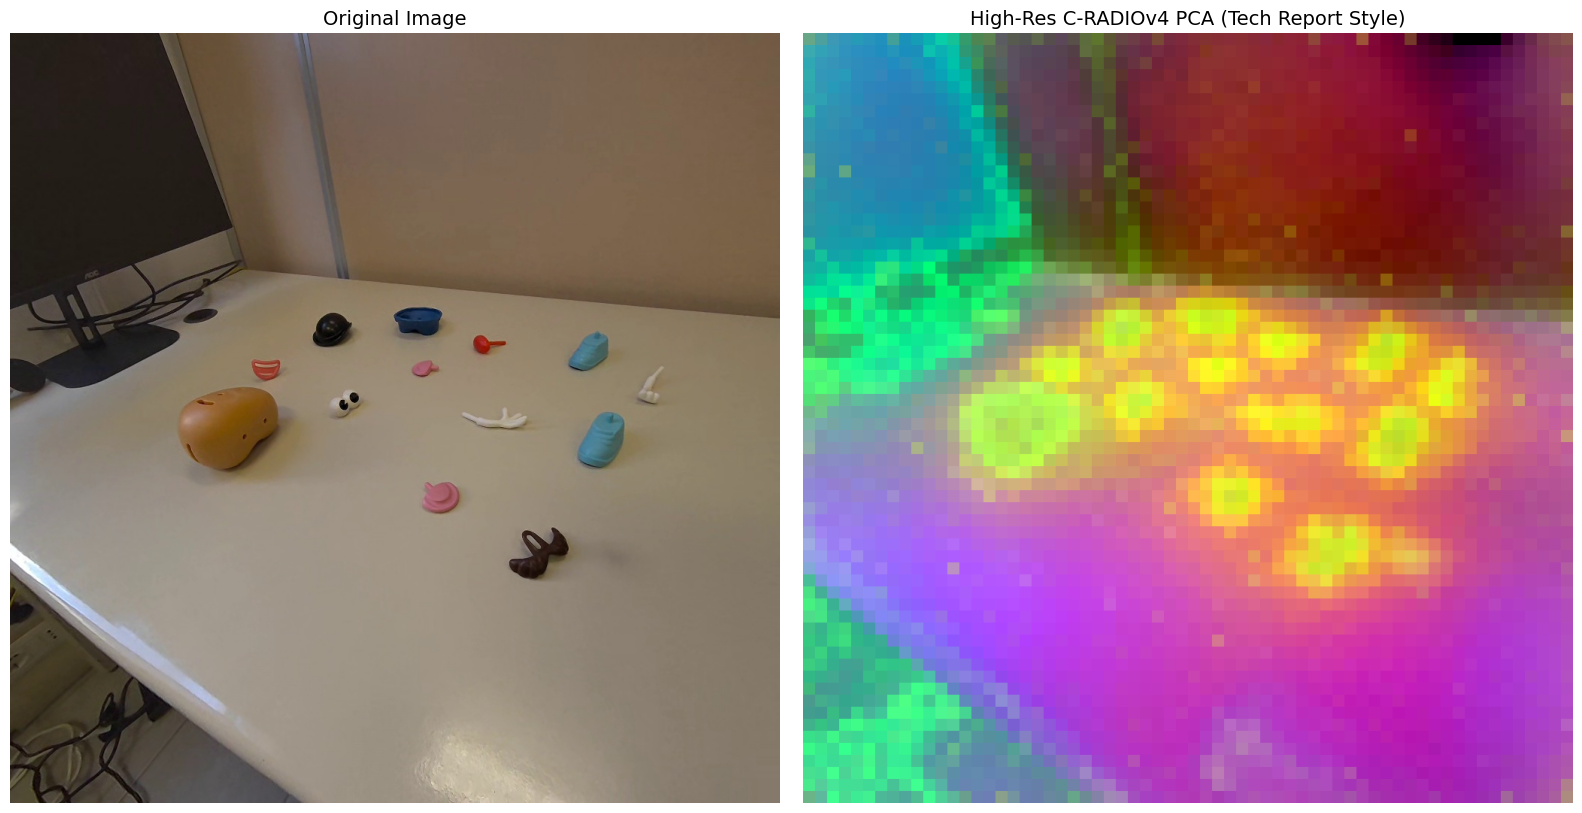

In [ ]:
# Cell 3: High-Resolution Feature Extraction & Tech Report Style PCA
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
from einops import rearrange
from sklearn.decomposition import PCA

print("1. Calculating optimal high-resolution input...")
# Troviamo la risoluzione massima supportata più vicina a quella originale (multipli di 16)
nearest_h, nearest_w = model.get_nearest_supported_resolution(height=image.height, width=image.width)
print(f"Original size: {image.width}x{image.height} -> Target size: {nearest_w}x{nearest_h}")

# Ridimensioniamo manualmente l'immagine alla massima risoluzione supportata
image_resized = image.resize((nearest_w, nearest_h), Image.Resampling.LANCZOS)

# Disattiviamo il do_resize del processore per non fargli rimpicciolire il nostro lavoro
inputs = image_processor(images=image_resized, return_tensors='pt', do_resize=False)
pixel_values = inputs.pixel_values.to(dtype=torch.bfloat16, device='cuda')

print("2. Extracting high-density spatial features...")
with torch.no_grad():
    with torch.autocast('cuda', dtype=torch.bfloat16):
        summary, features = model(pixel_values)

patch_size = model.patch_size if hasattr(model, 'patch_size') else 16
h_feat = nearest_h // patch_size
w_feat = nearest_w // patch_size
spatial_features = rearrange(features, 'b (h w) d -> b d h w', h=h_feat, w=w_feat)

print(f"Feature grid size: {w_feat}x{h_feat} patches")

print("3. Computing Robust PCA (Fitting only on central features)...")
c = spatial_features.shape[1]
margin = 2
central_features = spatial_features[0, :, margin:-margin, margin:-margin]
features_for_fit = central_features.permute(1, 2, 0).reshape(-1, c).float().cpu().numpy()

pca = PCA(n_components=3)
pca.fit(features_for_fit)

features_all = spatial_features.squeeze(0).permute(1, 2, 0).reshape(-1, c).float().cpu().numpy()
pca_features = pca.transform(features_all)

print("4. Normalizing for RGB visualization...")
pca_cleaned = np.zeros_like(pca_features)
for i in range(3):
    comp = pca_features[:, i]
    p_min, p_max = np.percentile(comp, 1), np.percentile(comp, 99)
    comp_clipped = np.clip(comp, p_min, p_max)
    pca_cleaned[:, i] = (comp_clipped - p_min) / (p_max - p_min + 1e-8)

pca_grid = pca_cleaned.reshape(h_feat, w_feat, 3)

# Usiamo l'effetto "a blocchi" fedele al Tech Report
pca_resized_plot = cv2.resize(pca_grid, (image.width, image.height), interpolation=cv2.INTER_NEAREST)

print("5. Plotting results...")
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(image)
axes[0].set_title("Original Image", fontsize=14)
axes[0].axis('off')

axes[1].imshow(pca_resized_plot)
axes[1].set_title("High-Res C-RADIOv4 PCA", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()